In [1]:
# ── CÉLULA 1: Instalação de dependências ──────────────────────
!pip install pymupdf pillow requests pandas openpyxl -q
!ollama list

NAME            ID              SIZE      MODIFIED    
qwen2.5vl:3b    fb90415cde1e    3.2 GB    9 days ago     
qwen3-vl:8b     901cae732162    6.1 GB    2 weeks ago    
qwen2.5:7b      845dbda0ea48    4.7 GB    3 weeks ago    


In [2]:
# ── CÉLULA 2: Imports ──────────────────────────────────────────
import json
import re
import base64
import requests
import pandas as pd
import fitz
from PIL import Image
from io import BytesIO
from IPython.display import display, HTML
from pathlib import Path
import time

print("Imports carregados com sucesso")

Imports carregados com sucesso


In [3]:
# ── CÉLULA 3: Configuração ─────────────────────────────────────
#  AJUSTA AQUI

# Modelos disponíveis — testa qual funciona melhor no teu caso
MODEL = "qwen3-vl:8b"          # modelo principal (vision)
# MODEL = "minicpm-v:8b"         # outra alternativa

OLLAMA_URL = "http://localhost:11434/api/chat"

# ── PDFs a processar ──
# Opção A: lista manual
PDF_PATHS = [
    "labreport_14.pdf",
    # "labreport_9.pdf",  # adiciona mais PDFs aqui
]

# Opção B: processar TODOS os PDFs na pasta atual (descomenta para usar)
# PDF_PATHS = list(Path(".").glob("*.pdf"))

# ── Qualidade das imagens ──
# Maior zoom = melhor qualidade mas mais lento
# 1.5 → ~108 DPI | 2.0 → ~144 DPI | 2.5 → ~180 DPI
ZOOM = 2.0

# ── Timeouts e tentativas ──
# Valores mais baixos para evitar bloqueios longos
TIMEOUT_SEGUNDOS = 90        # tempo máximo por pedido (segundos)
MAX_TENTATIVAS = 1           # começa com 1 tentativa por página
PAUSA_ENTRE_TENTATIVAS = 3   # segundos entre tentativas

print(f"Configuração pronta")
print(f"   Modelo: {MODEL}")
print(f"   PDFs: {PDF_PATHS}")

Configuração pronta
   Modelo: qwen3-vl:8b
   PDFs: ['labreport_14.pdf']


In [4]:
# ── CÉLULA 4: Verificar ligação ao Ollama ─────────────────────

def verificar_ollama(url=OLLAMA_URL, modelo=MODEL):
    """Verifica se o Ollama está a correr e se o modelo está disponível."""
    base_url = url.replace("/api/chat", "")
    
    # 1. Verificar se o servidor está ativo
    try:
        r = requests.get(f"{base_url}/api/tags", timeout=10)
        r.raise_for_status()
    except requests.exceptions.ConnectionError:
        print("❌ Ollama não está a correr!")
        print("   Solução: Abre um terminal e executa:  ollama serve")
        return False
    except Exception as e:
        print(f"❌ Erro ao ligar ao Ollama: {e}")
        return False
    
    # 2. Verificar se o modelo está disponível
    modelos_disponiveis = [m["name"] for m in r.json().get("models", [])]
    modelo_base = modelo.split(":")[0]
    
    modelo_encontrado = any(
        m == modelo or m.startswith(modelo_base)
        for m in modelos_disponiveis
    )
    
    if not modelo_encontrado:
        print(f"⚠️  Modelo '{modelo}' não encontrado!")
        print(f"   Modelos disponíveis: {modelos_disponiveis}")
        print(f"   Solução: ollama pull {modelo}")
        return False
    
    print(f"✅ Ollama está a correr")
    print(f"✅ Modelo '{modelo}' disponível")
    return True

ollama_ok = verificar_ollama()
if not ollama_ok:
    print("\n🛑 Resolve os erros acima antes de continuar.")

✅ Ollama está a correr
✅ Modelo 'qwen3-vl:8b' disponível


In [5]:
# ── CÉLULA 5: Prompt de extração ───────────────────────────────

PROMPT = """Tu és um expert em análise de relatórios laboratoriais.

Analisa esta imagem de um relatório de análises e extrai TODOS os resultados.

Responde APENAS com um array JSON válido, sem texto antes ou depois, sem ```json.

Formato obrigatório:
[
  {
    "name": "nome da análise",
    "value": "valor medido",
    "unit": "unidade",
    "reference": "intervalo de referência",
    "flag": "HIGH ou LOW ou ABNORMAL ou vazio"
  }
]

Regras:
- Extrai TODOS os parâmetros visíveis
- Se o valor está acima do normal: flag = "HIGH"
- Se o valor está abaixo do normal: flag = "LOW"
- Se está marcado como anormal sem direção: flag = "ABNORMAL"
- Se está normal: flag = ""
- Se não há unidade: unit = ""
- Se não há referência: reference = ""
- Ignora títulos, cabeçalhos e notas
- Se a página não contém análises: retorna []"""

print("✅ Prompt carregado")

✅ Prompt carregado


In [6]:
# ── CÉLULA 6: Funções auxiliares ───────────────────────────────

def pdf_para_imagens(pdf_path, zoom=ZOOM):
    """Converte um PDF em lista de imagens PIL."""
    pdf_path = Path(pdf_path)
    if not pdf_path.exists():
        print(f"❌ Ficheiro não encontrado: {pdf_path}")
        return []
    
    try:
        doc = fitz.open(str(pdf_path))
        imagens = []
        for i in range(len(doc)):
            pagina = doc[i]
            matriz = fitz.Matrix(zoom, zoom)
            pixmap = pagina.get_pixmap(matrix=matriz)
            imagem = Image.frombytes("RGB", [pixmap.width, pixmap.height], pixmap.samples)
            imagens.append(imagem)
        doc.close()
        print(f"   📄 {pdf_path.name}: {len(imagens)} página(s) convertida(s) ({imagens[0].size[0]}x{imagens[0].size[1]}px)")
        return imagens
    except Exception as e:
        print(f"❌ Erro ao abrir {pdf_path}: {e}")
        return []


def imagem_para_base64(imagem):
    """Converte imagem PIL para string base64."""
    buffer = BytesIO()
    imagem.save(buffer, format="PNG")
    return base64.b64encode(buffer.getvalue()).decode("utf-8")


def extrair_json_da_resposta(texto):
    """Extrai JSON válido de uma resposta do modelo (mesmo que contenha texto extra)."""
    # Remover marcadores de código
    texto = re.sub(r"```(?:json)?\s*", "", texto).strip().rstrip("`")
    
    # Tentar parse direto
    try:
        dados = json.loads(texto)
        if isinstance(dados, list):
            return dados
        if isinstance(dados, dict):
            return dados.get("analyses", dados.get("results", dados.get("data", [])))
    except json.JSONDecodeError:
        pass
    
    # Tentar encontrar array JSON dentro do texto
    match = re.search(r'\[.*\]', texto, re.DOTALL)
    if match:
        try:
            return json.loads(match.group())
        except json.JSONDecodeError:
            pass
    
    return None  # Falhou completamente


def enviar_ao_ollama(imagem, pagina_info="", tentativa=1):
    """Envia uma imagem ao Ollama e retorna as análises extraídas."""
    imagem_b64 = imagem_para_base64(imagem)
    
    pedido = {
        "model": MODEL,
        "stream": False,
        "messages": [
            {"role": "system", "content": PROMPT},
            {"role": "user", "content": "Extrai as análises desta imagem.", "images": [imagem_b64]}
        ],
        "options": {"temperature": 0.1, "think": False}
    }
    
    try:
        resposta = requests.post(OLLAMA_URL, json=pedido, timeout=TIMEOUT_SEGUNDOS)
        resposta.raise_for_status()
        texto = resposta.json()["message"]["content"]
        
        dados = extrair_json_da_resposta(texto)
        
        if dados is None:
            print(f"   ⚠️  JSON inválido {pagina_info}. Resposta: {texto[:150]}...")
            return None, "json_invalido"
        
        return dados, "ok"
    
    except requests.exceptions.ConnectionError:
        print(f"   ❌ Sem ligação ao Ollama {pagina_info}")
        return None, "sem_ligacao"
    
    except requests.exceptions.Timeout:
        print(f"   ⏱️  Timeout {pagina_info} (>{TIMEOUT_SEGUNDOS}s)")
        return None, "timeout"
    
    except Exception as e:
        print(f"   ❌ Erro inesperado {pagina_info}: {e}")
        return None, "erro_desconhecido"


print("✅ Funções carregadas")

✅ Funções carregadas


In [7]:
# ── CÉLULA 7: Processamento principal ─────────────────────────
# Processa todos os PDFs com tratamento de erros e tentativas automáticas

todos_os_resultados = []   # todos os registos extraídos
erros = []                 # páginas que falharam
estatisticas = {}          # resumo por ficheiro

print("🚀 Iniciando processamento...\n")
inicio_total = time.time()

for pdf_path in PDF_PATHS:
    pdf_path = Path(pdf_path)
    print(f"\n📂 A processar: {pdf_path}")
    
    # Converter PDF em imagens
    imagens = pdf_para_imagens(pdf_path)
    if not imagens:
        estatisticas[str(pdf_path)] = {"paginas": 0, "analises": 0, "erros": 0}
        continue
    
    analises_deste_pdf = 0
    erros_deste_pdf = 0
    
    for num_pagina, imagem in enumerate(imagens):
        pagina_info = f"(PDF: {pdf_path.name}, pág. {num_pagina + 1}/{len(imagens)})"
        print(f"\n   ⏳ A processar página {num_pagina + 1}/{len(imagens)}...", end="")
        
        dados = None
        status_final = "falhou"
        
        for tentativa in range(1, MAX_TENTATIVAS + 1):
            if tentativa > 1:
                print(f"\n   🔄 Tentativa {tentativa}/{MAX_TENTATIVAS}...", end="")
                time.sleep(PAUSA_ENTRE_TENTATIVAS)
            
            dados, status = enviar_ao_ollama(imagem, pagina_info, tentativa)
            
            if status == "sem_ligacao":
                print("\n🛑 Ollama não acessível. A parar.")
                break
            
            if dados is not None:
                status_final = "ok"
                break
        
        if dados is None:
            print(f" ❌ Página falhou após {MAX_TENTATIVAS} tentativas")
            erros.append({"pdf": str(pdf_path), "pagina": num_pagina + 1})
            erros_deste_pdf += 1
            continue
        
        # Adicionar metadados a cada registo
        for registo in dados:
            registo["_pdf"] = pdf_path.name
            registo["_pagina"] = num_pagina + 1
        
        todos_os_resultados.extend(dados)
        analises_deste_pdf += len(dados)
        print(f" ✅ {len(dados)} análise(s)")
    
    estatisticas[str(pdf_path)] = {
        "paginas": len(imagens),
        "analises": analises_deste_pdf,
        "erros": erros_deste_pdf
    }

duracao = round(time.time() - inicio_total, 1)
print(f"\n{'='*50}")
print(f"✅ Processamento concluído em {duracao}s")
print(f"   Total de análises extraídas: {len(todos_os_resultados)}")
print(f"   Páginas com erro: {len(erros)}")

if erros:
    print("\n⚠️  Páginas que falharam:")
    for e in erros:
        print(f"   - {e['pdf']}, pág. {e['pagina']}")

🚀 Iniciando processamento...


📂 A processar: labreport_14.pdf
   📄 labreport_14.pdf: 1 página(s) convertida(s) (1191x1684px)

   ⏳ A processar página 1/1...   ⏱️  Timeout (PDF: labreport_14.pdf, pág. 1/1) (>90s)
 ❌ Página falhou após 1 tentativas

✅ Processamento concluído em 92.8s
   Total de análises extraídas: 0
   Páginas com erro: 1

⚠️  Páginas que falharam:
   - labreport_14.pdf, pág. 1


In [8]:
# ── CÉLULA 8: Resumo por ficheiro ──────────────────────────────

print("📊 Resumo por ficheiro:")
print(f"{'Ficheiro':<30} {'Páginas':>8} {'Análises':>10} {'Erros':>7}")
print("-" * 60)
for pdf, stats in estatisticas.items():
    nome = Path(pdf).name
    print(f"{nome:<30} {stats['paginas']:>8} {stats['analises']:>10} {stats['erros']:>7}")

📊 Resumo por ficheiro:
Ficheiro                        Páginas   Análises   Erros
------------------------------------------------------------
labreport_14.pdf                      1          0       1


In [9]:
# ── CÉLULA 9: Visualização colorida ───────────────────────────

if not todos_os_resultados:
    print("⚠️  Sem resultados para mostrar.")
else:
    df = pd.DataFrame(todos_os_resultados)
    
    # Reordenar colunas (metadados por último)
    colunas_dados = [c for c in ["name", "value", "unit", "reference", "flag"] if c in df.columns]
    colunas_meta = [c for c in df.columns if c.startswith("_")]
    df = df[colunas_dados + colunas_meta]
    
    def colorir_linha(row):
        flag = str(row.get("flag", "")).upper()
        if flag == "HIGH":
            return ["background-color: #ffe0e0"] * len(row)
        elif flag == "LOW":
            return ["background-color: #fff3cd"] * len(row)
        elif flag == "ABNORMAL":
            return ["background-color: #f0e0ff"] * len(row)
        return [""] * len(row)
    
    print(f"📋 {len(df)} análise(s) encontrada(s):\n")
    display(df.style.apply(colorir_linha, axis=1))

⚠️  Sem resultados para mostrar.


In [10]:
# ── CÉLULA 10: Exportar resultados ────────────────────────────
# Guarda os resultados em CSV e Excel

if todos_os_resultados:
    df.to_csv("resultados_analises.csv", index=False, encoding="utf-8-sig")
    df.to_excel("resultados_analises.xlsx", index=False)
    
    with open("resultados_analises.json", "w", encoding="utf-8") as f:
        json.dump(todos_os_resultados, f, ensure_ascii=False, indent=2)
    
    print("✅ Ficheiros guardados:")
    print("   📄 resultados_analises.csv")
    print("   📊 resultados_analises.xlsx")
    print("   📋 resultados_analises.json")
else:
    print("⚠️  Sem resultados para exportar.")

⚠️  Sem resultados para exportar.


🔍 Modo DEBUG — labreport_14.pdf, pág. 1

   📄 labreport_14.pdf: 1 página(s) convertida(s) (1191x1684px)


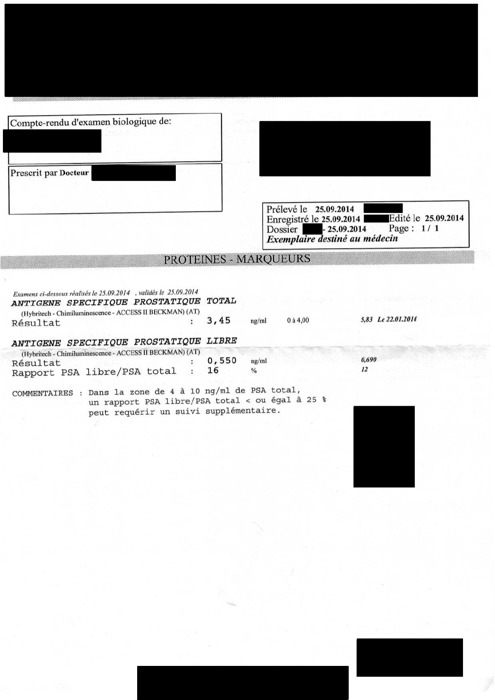


📤 A enviar ao modelo...


ReadTimeout: HTTPConnectionPool(host='localhost', port=11434): Read timed out. (read timeout=90)

In [11]:
# ── CÉLULA 11 [DEBUG]: Testar o modelo numa página específica ──
# Útil para ver exactamente o que o modelo responde antes de processar tudo

PDF_TESTE = PDF_PATHS[0]      # PDF a usar no teste
PAGINA_TESTE = 0              # índice da página (0 = primeira)

print(f"🔍 Modo DEBUG — {Path(PDF_TESTE).name}, pág. {PAGINA_TESTE + 1}\n")

imagens_teste = pdf_para_imagens(PDF_TESTE)
if imagens_teste:
    imagem_debug = imagens_teste[PAGINA_TESTE]
    
    # Mostrar imagem
    previa = imagem_debug.copy()
    previa.thumbnail((700, 700))
    display(previa)
    
    # Enviar ao modelo e mostrar resposta crua
    print("\n📤 A enviar ao modelo...")
    imagem_b64 = imagem_para_base64(imagem_debug)
    pedido = {
        "model": MODEL,
        "stream": False,
        "messages": [
            {"role": "system", "content": PROMPT},
            {"role": "user", "content": "Extrai as análises desta imagem.", "images": [imagem_b64]}
        ],
        "options": {"temperature": 0.1, "think": False}
    }
    resposta = requests.post(OLLAMA_URL, json=pedido, timeout=TIMEOUT_SEGUNDOS)
    texto_cru = resposta.json()["message"]["content"]
    
    print("\n📥 Resposta crua do modelo:")
    print(texto_cru)
    
    print("\n📊 JSON extraído:")
    dados_debug = extrair_json_da_resposta(texto_cru)
    if dados_debug:
        print(json.dumps(dados_debug, indent=2, ensure_ascii=False))
    else:
        print("❌ Não foi possível extrair JSON válido")